# <font color="red">**H7: EELS Clustering Challenge**</font>

## Spectral data → EELS clustering and dimensional reduction

An EELS spectrum contains many energy channels, so every pixel can be viewed as a point in a **high-dimensional spectral space**.

Today we will ask:

> **Can we find meaningful groups of EELS spectra, and do we recover the same groups after reducing the dimensionality?**

### Your tasks

1. Explore the EELS spectral dataset.
2. Cluster spectra in the **original high-dimensional space**.
3. Reduce the spectra with **PCA**.
4. Cluster again in the **low-dimensional PCA space**.
5. Compare the two cluster maps.
6. Measure how strongly the cluster assignments overlap.
7. Decide what makes a clustering result **good or bad**.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbarakati/athena_camm_hackathon/blob/k4my4r/docs/day_18_25092026/eels_clustering_hackathon.ipynb)

<h2><font color="purple">1.</font> Load the Dataset</h2>

<p>
Each spatial pixel contains one complete <b>EELS spectrum</b>.
</p>

<p style="font-size:18px;">
(x, y) &rarr; I(E)
</p>

<p>
If the spectral image has dimensions:
</p>

<p style="font-size:18px;">
H &times; W &times; N<sub>E</sub>
</p>

<p>
then:
</p>

<ul>
  <li><b>H</b> = image height</li>
  <li><b>W</b> = image width</li>
  <li><b>N<sub>E</sub></b> = number of energy channels in each spectrum</li>
</ul>

<p>
Therefore, every spatial pixel contains <b>N<sub>E</sub> spectral features</b>.
</p>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
)
from sklearn.metrics.cluster import contingency_matrix

In [2]:
# Download data in Google Colab
!gdown --fuzzy 1FKmlRTRDImQS91V4YQjcQHoJU19X6P_6

Downloading...
From (original): https://drive.google.com/uc?id=1FKmlRTRDImQS91V4YQjcQHoJU19X6P_6
From (redirected): https://drive.google.com/uc?id=1FKmlRTRDImQS91V4YQjcQHoJU19X6P_6&confirm=t&uuid=999f5945-cbfc-4a1c-93f5-d08026c5d04d
To: /content/Plasmonic_sets_hackathon.npy
100% 584M/584M [00:07<00:00, 73.5MB/s]


In [3]:
file_name = "/content/Plasmonic_sets_hackathon.npy"

raw = np.load(file_name, allow_pickle=True)
loadedfile = raw.tolist()

print("Available datasets:", loadedfile.keys())

Available datasets: dict_keys(['0', '1', '2', '3'])


In [4]:
# Use the same dataset as the previous challenge
data = loadedfile["2"]

image = data["image"]
spectra = data["spectrum image"]
energy = data["energy axis"]

H, W, N_E = spectra.shape

print("Image:", image.shape)
print("Spectral image:", spectra.shape)
print("Energy axis:", energy.shape)

Image: (33, 63)
Spectral image: (33, 63, 4322)
Energy axis: (4322,)


## <font color="purple">**2.**</font> Explore the Spectra

Before clustering, always look at the data.

The structural image tells us **where** each spectrum was measured.  
The spectra tell us **what the local EELS response looks like**.

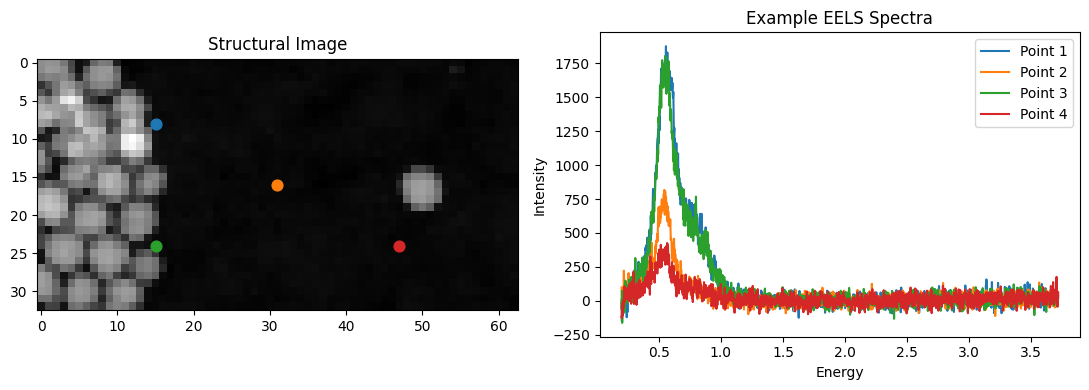

In [5]:
# Pick a few example locations
positions = [
    (H // 4, W // 4),
    (H // 2, W // 2),
    (3 * H // 4, W // 4),
    (3 * H // 4, 3 * W // 4),
]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].imshow(image, cmap="gray")
ax[0].set_title("Structural Image")

for i, (y, x) in enumerate(positions):
    ax[0].scatter(x, y, s=60)
    ax[1].plot(energy, spectra[y, x], label=f"Point {i + 1}")

ax[1].set_title("Example EELS Spectra")
ax[1].set_xlabel("Energy")
ax[1].set_ylabel("Intensity")
ax[1].legend()

plt.tight_layout()
plt.show()

## <font color="purple">**3.**</font> Convert the Spectral Image into a Data Matrix

Clustering algorithms expect a table:

- **rows** = samples
- **columns** = features

For EELS:

- one **pixel** = one sample
- one **energy channel** = one feature

So we reshape

(H, W, N<sub>E</sub>) &rarr; (H &times; W, N<sub>E</sub>)

In [6]:
X = spectra.reshape(-1, N_E)

print("Clustering matrix:", X.shape)
print("Number of spectra:", X.shape[0])
print("Features per spectrum:", X.shape[1])

Clustering matrix: (2079, 4322)
Number of spectra: 2079
Features per spectrum: 4322


## <font color="purple">**4.**</font> Standardize the Spectral Features

Different energy channels can have very different intensity scales.

Standardization transforms each feature approximately to:

z = <span style="display:inline-block; text-align:center;">
  <span style="border-bottom:1px solid; display:block;">x - &mu;</span>
  <span style="display:block;">&sigma;</span>
</span>

This prevents a large-intensity energy channel from dominating only because of its numerical scale.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data:", X_scaled.shape)

Scaled data: (2079, 4322)


# Worked Example

Before the challenge, here is **one complete example**.

We will use:

- **K-Means**
- \(k=3\) clusters
- the full standardized EELS spectrum

K-Means assigns spectra to groups so that spectra inside a cluster are as similar as possible.

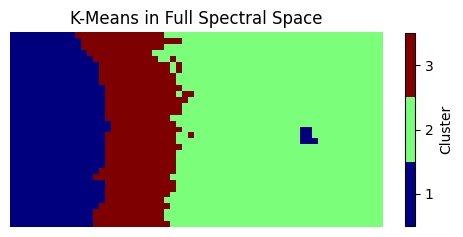

In [8]:
# Example: cluster the full spectra

k = 3

model = KMeans(n_clusters=k, random_state=0, n_init=10)
labels_high = model.fit_predict(X_scaled)

cluster_map_high = labels_high.reshape(H, W) + 1

plt.figure(figsize=(6, 5))

im = plt.imshow(
    cluster_map_high,
    cmap=plt.get_cmap("jet", k),
    vmin=0.5,
    vmax=k + 0.5
)

plt.colorbar(im, ticks=range(1, k + 1), label="Cluster", shrink = 0.5)
plt.title("K-Means in Full Spectral Space")
plt.axis("off")
plt.show()

<h3>What did we just do?</h3>

<p>
Each EELS spectrum originally contained <b>N<sub>E</sub> spectral features</b>.
</p>

<p>
K-Means therefore grouped the spectra directly in an
<b>N<sub>E</sub>-dimensional feature space</b>.
</p>

<p>
The resulting cluster map is our
<b>high-dimensional clustering result</b>.
</p>

<p>
Next, we will reduce the dimensionality of the spectra and ask:
</p>

<p style="font-size:18px;">
<b>Do we recover the same clustering using fewer features?</b>
</p>

# <font color="red">Challenge 1</font> — High-Dimensional Clustering

Choose a number of clusters and cluster the **full standardized spectra**.

Try values such as:

- \(k=2\)
- \(k=3\)
- \(k=4\)
- \(k=5\)

### Question

> Does the cluster map form physically meaningful spatial regions, or does it look fragmented/noisy?

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

k = 2

# Create Clustering model
# Fit the model to X_scaled
# Store the labels in labels_high
# Reshape labels into cluster_map_high


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

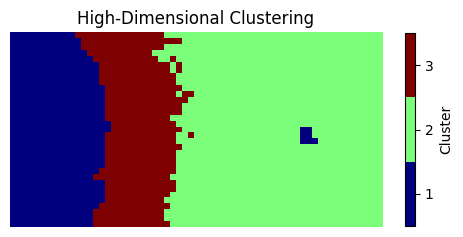

In [ ]:
# Plot your result

plt.figure(figsize=(6, 5))

plt.imshow(
    cluster_map_high,
    cmap=plt.get_cmap("jet", k),
    vmin=0.5,
    vmax=k + 0.5
)

plt.colorbar(
    ticks=range(1, k + 1),
    label="Cluster", shrink = .5
)

plt.title("High-Dimensional Clustering")
plt.axis("off")
plt.show()

<h2><font color="purple">5.</font> Dimensional Reduction with PCA</h2>

<p>
EELS spectra can contain a large number of energy channels.
Many of these channels are correlated, meaning they do not all provide completely independent information.
</p>

<p>
<b>Principal Component Analysis (PCA)</b> reduces the dimensionality of the spectra by representing them with a smaller number of new features called <b>principal components</b>.
</p>

<p>
Instead of describing each spectrum using:
</p>

<p style="font-size:18px;">
N<sub>E</sub> spectral features
</p>

<p>
we can describe it using only:
</p>

<p style="font-size:18px;">
PC<sub>1</sub>, PC<sub>2</sub>, ..., PC<sub>n</sub>
</p>

<p>
The goal is to use fewer dimensions while preserving as much of the important spectral variation as possible.
</p>

<p>
This gives us a <b>low-dimensional representation</b> of the original EELS spectra.
</p>

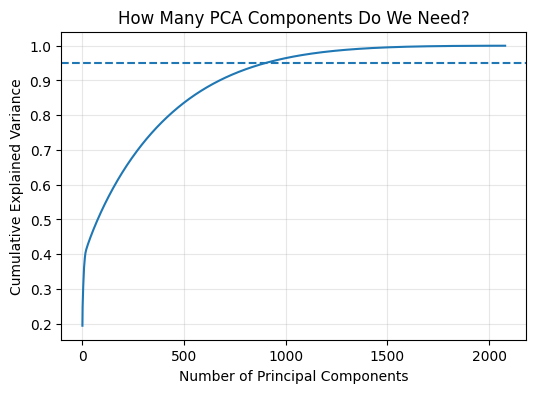

In [ ]:
# First inspect how much information PCA keeps

pca_all = PCA()
pca_all.fit(X_scaled)

variance = np.cumsum(pca_all.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(variance) + 1), variance)
plt.axhline(0.95, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("How Many PCA Components Do We Need?")
plt.grid(alpha=0.3)
plt.show()

# <font color="red">Challenge 2</font> — Low-Dimensional Clustering

Choose a small number of PCA components.

For example:

```python
n_components = 3
```

Then:

1. reduce the spectra with PCA,
2. cluster the reduced data with K-Means,
3. reshape the labels into an image.

### Question

> Can a few PCA components reproduce the structure found using the full spectrum?

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

n_components = 3

# Run PCA
# X_pca = ...

# Cluster X_pca using the same k
# labels_low = ...

# Reshape labels
# cluster_map_low = ...


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

In [ ]:
# Plot your PCA clustering result

plt.figure(figsize=(6, 5))
plt.imshow(cluster_map_low, cmap="tab10")
plt.colorbar(label="Cluster")
plt.title(f"Clustering after PCA ({n_components} components)")
plt.axis("off")
plt.show()

## <font color="purple">**6.**</font> Compare High- and Low-Dimensional Results

Visual comparison is useful, but cluster labels can be misleading.

For example:

- high-dimensional cluster `0`
- low-dimensional cluster `2`

may represent the **same physical group**.

Therefore, do **not** compare cluster numbers directly.

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

ax[0].imshow(image, cmap="gray")
ax[0].set_title("Structural Image")

ax[1].imshow(cluster_map_high, cmap="tab10")
ax[1].set_title("Full Spectral Space")

ax[2].imshow(cluster_map_low, cmap="tab10")
ax[2].set_title("PCA Space")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

# <font color="red">Challenge 3</font> — How Much Do the Labels Overlap?

We need a comparison that is independent of the numerical cluster labels.

We will use the **Adjusted Rand Index (ARI)**.

\[
ARI \approx 1
\]

means the two clusterings assign points to very similar groups.

\[
ARI \approx 0
\]

means their agreement is close to random.

The **contingency matrix** also shows how clusters from one solution map onto clusters from the other.

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

# Calculate Adjusted Rand Index
# ari = ...

# Calculate overlap / contingency matrix
# overlap = ...


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

print(f"Adjusted Rand Index: {ari:.3f}")
print("\nCluster overlap matrix:")
print(overlap)

<h2><font color="purple">7.</font> What Makes Clustering Good or Bad?</h2>

<p>
In unsupervised clustering, we usually do not have ground-truth labels.
Therefore, we evaluate clustering using <b>internal quality metrics</b>.
</p>

<p>Here we will use two common metrics:</p>

<hr>

<h3>Silhouette Score</h3>

<p>
The Silhouette Score measures how well each point fits within its assigned cluster.
A good point should be:
</p>

<ul>
  <li>close to other points in the <b>same cluster</b></li>
  <li>far from points in <b>neighboring clusters</b></li>
</ul>

<p><b>Range:</b></p>

<p style="font-size:18px;">
-1 &le; S &le; 1
</p>

<ul>
  <li><b>Higher is better</b></li>
  <li>Values near 1 indicate well-separated clusters</li>
  <li>Values near 0 indicate overlapping clusters</li>
  <li>Negative values may indicate poor assignments</li>
</ul>

<hr>

<h3>Davies–Bouldin Score</h3>

<p>
The Davies–Bouldin Score measures how compact the clusters are
and how well separated they are from each other.
</p>

<p><b>Range:</b></p>

<p style="font-size:18px;">
DB &ge; 0
</p>

<ul>
  <li><b>Lower is better</b></li>
  <li>Smaller values indicate compact, well-separated clusters</li>
</ul>

<hr>

<p>
<b>Important:</b> A good numerical clustering score does not automatically mean
that the clusters are physically meaningful.
</p>

<p>
For EELS data, we should also inspect the spatial cluster maps and the average
spectrum of each cluster.
</p>

# <font color="red">Challenge 4</font> — Score Both Clusterings

Calculate the clustering quality in:

1. the full spectral space,
2. the PCA-reduced space.

### Important

Evaluate each set of labels in the **same feature space in which it was clustered**.

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

# High-dimensional clustering
# sil_high = ...
# db_high = ...

# Low-dimensional clustering
# sil_low = ...
# db_low = ...


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

print("Full spectral space")
print(f"  Silhouette:      {sil_high:.3f}")
print(f"  Davies-Bouldin:  {db_high:.3f}")

print("\nPCA space")
print(f"  Silhouette:      {sil_low:.3f}")
print(f"  Davies-Bouldin:  {db_low:.3f}")

## <font color="purple">**8.**</font> Inspect the Average Spectrum of Each Cluster

A clustering map is much easier to interpret if the clusters also have distinct spectral signatures.

For every cluster, calculate the **mean EELS spectrum**.

### Question

> Do the clusters differ in peak intensity, peak position, spectral shape, or background?

In [ ]:
# Example helper function

def plot_cluster_spectra(X, labels, energy):
    for label in np.unique(labels):
        mean_spectrum = X[labels == label].mean(axis=0)
        plt.plot(energy, mean_spectrum, label=f"Cluster {label}")

    plt.xlabel("Energy")
    plt.ylabel("Mean EELS Intensity")
    plt.title("Mean Spectrum of Each Cluster")
    plt.legend()
    plt.show()

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

# Use the original spectra X, not X_scaled,
# so the plotted spectra remain physically interpretable.

# plot_cluster_spectra(...)


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

# <font color="red">Final Challenge</font> — Find a Good Clustering

Systematically test different choices.

You may change:

- number of clusters \(k\)
- number of PCA components

For each experiment, record:

- \(k\)
- PCA dimensions
- explained variance
- Silhouette score
- Davies–Bouldin score
- ARI compared with the full-space clustering

### Your goal

> Find a low-dimensional representation that gives compact, separated clusters while preserving the grouping found in the original spectral space.

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

# Suggested experiment:
#
# for n_components in [2, 3, 5, 10]:
#     ...
#
# Try several k values too.
# Store the results and compare them.


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

## Final Discussion

Be ready to explain your result.

### 1. High vs. low dimensional space
Did PCA change the clustering substantially?

### 2. Cluster overlap
Was the ARI high or low? What does that tell you?

### 3. Quality
Which solution had:

- higher Silhouette score?
- lower Davies–Bouldin score?

### 4. Physics
Do the clusters correspond to:

- spatially coherent regions?
- different EELS spectral signatures?
- visible structural regions?

### 5. Complexity
How many PCA components were actually necessary?

---

## <font color="green">Takeaway</font>

A clustering result is not good simply because an algorithm produced labels.

A useful clustering should ideally be:

- **well separated**
- **internally compact**
- **stable under dimensional reduction**
- **spectrally interpretable**
- **spatially or physically meaningful**